<a href="https://colab.research.google.com/github/sweethusband73/llm-translation-evaluation-chart/blob/main/comet-22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

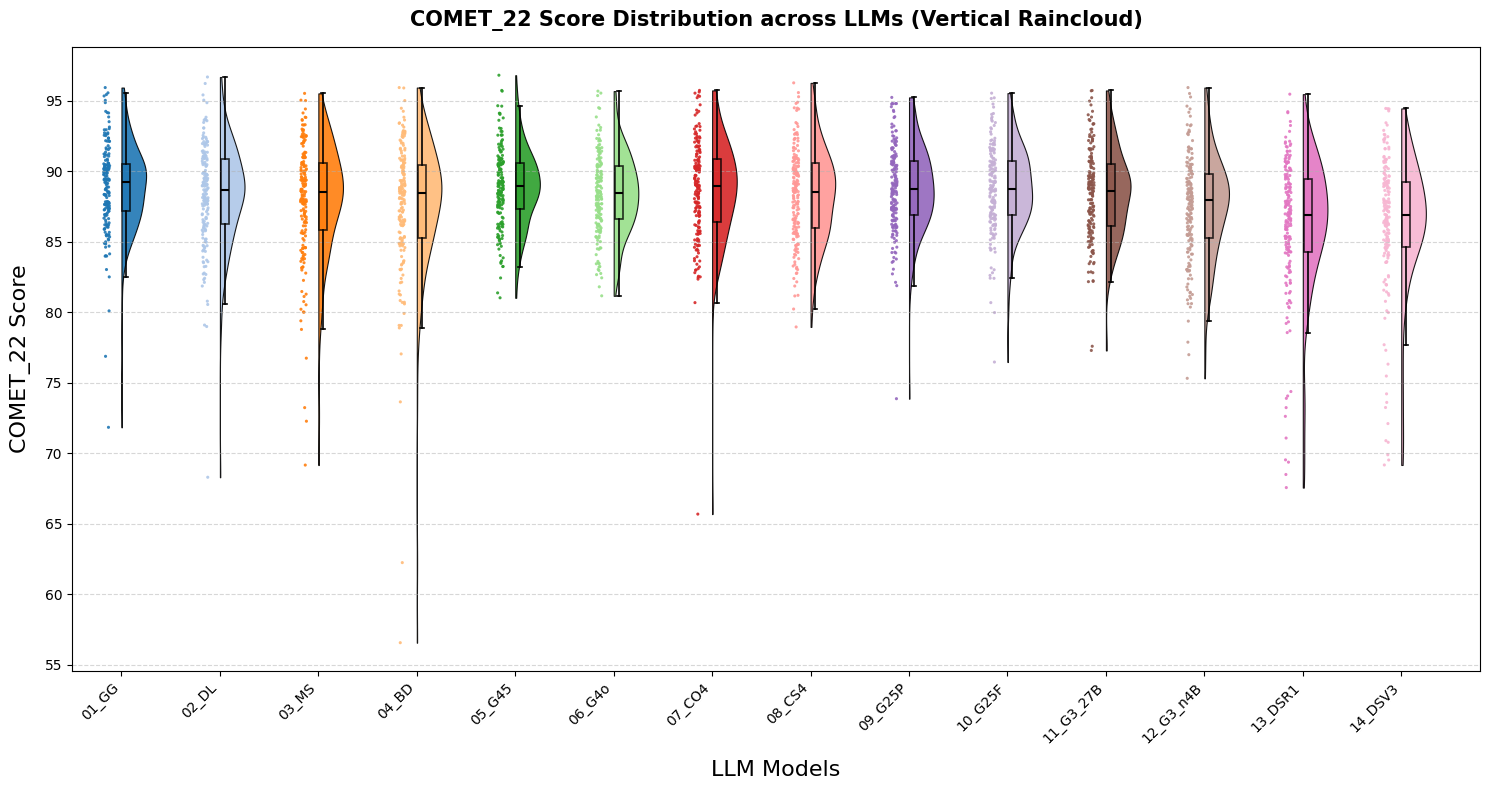

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 讀取您的 CSV 檔案
df = pd.read_csv("1_Repeated_ANOVA_COMET_0714_OK.csv")

# 2. 寬格式轉長格式
model_cols = df.columns[1:]
df_long = pd.melt(df, id_vars=['Sentence_ID'], value_vars=model_cols, var_name='LLM_Model', value_name='Score')

# 確保 'Score' 欄位是數值型態，並處理非數值資料 (保留您優良的清洗步驟)
df_long['Score'] = pd.to_numeric(df_long['Score'], errors='coerce')
df_long.dropna(subset=['Score'], inplace=True)

# 3. 設定畫布尺寸
fig, ax = plt.subplots(figsize=(15, 8))
models = list(model_cols)
colors = sns.color_palette("tab20", len(models)) # 再次更換為 tab20 色板，提供更鮮明的顏色

# 4. 【核心修正】純手工精準定位：徹底解決「對稱小提琴」與「元素全部疊死在中間」的錯誤
for i, model in enumerate(models):
    # 篩選單一 LLM 模型的得分數據
    sub_data = df_long[df_long['LLM_Model'] == model]['Score'].values
    if len(sub_data) == 0:
        continue
    color = colors[i]

    # ─── 【右側】單邊雲朵：利用數學分佈手工畫出「單邊平滑核密度圖」 ───
    kde = gaussian_kde(sub_data)
    y_vals = np.linspace(sub_data.min(), sub_data.max(), 200)
    x_vals = kde(y_vals)
    x_vals = (x_vals / x_vals.max()) * 0.25  # 標準化寬度，防止相鄰模型圖表打架
    # 讓雲朵從基準點 i 開始只往「右邊」長 (i 到 i + x_vals)
    ax.fill_betweenx(y_vals, i, i + x_vals, color=color, alpha=0.9, edgecolor='black', linewidth=0.8)

    # ─── 【中間】細木箱：精準推移位置到 i + 0.05，絕不與雨滴和雲朵疊死 ───
    ax.boxplot(sub_data, positions=[i + 0.05], widths=0.08, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, color='black', alpha=0.8, linewidth=1.2),
               medianprops=dict(color='black', linewidth=1.5),
               whiskerprops=dict(color='black', linewidth=1.2),
               capprops=dict(color='black', linewidth=1.2))

    # ─── 【左側】微型雨滴：精準偏移到左邊 i - 0.15，並用極小點解決密集恐懼症 ───
    # 橫向擴散(jitter)嚴格限制在 0.03 內，並且 100% 移除了口試委員反對的灰色連線
    x_jitter = i - 0.15 + np.random.uniform(-0.03, 0.03, size=len(sub_data))
    ax.scatter(x_jitter, sub_data, color=color, alpha=0.9, s=5, edgecolor='none')

# 5. 調整標題、座標軸與字體
ax.set_title("COMET_22 Score Distribution across LLMs (Vertical Raincloud)", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("LLM Models", fontsize=16, labelpad=10) # 再次增大字體
ax.set_ylabel("COMET_22 Score", fontsize=16, labelpad=10) # 再次增大字體

# 固定 X 軸的標籤與位置，確保 14 個模型對齊得整整齊齊
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.set_xlim(-0.5, len(models) - 0.2)
plt.yticks(fontsize=10)

# 加入淡灰色橫向虛線，方便口試時橫向對比各模型高低
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("LLM_Vertical_Raincloud_Perfect.png", dpi=300) # 匯出300dpi高解析度論文插圖
plt.show()